## LSTM ile Metin Oluşturma Dil Modeli

## 1 - Kütüphanelerin İçeri Aktarılması

In [1]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Embedding, LSTM
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

# 2 - Veri Seti Oluşturulması

In [2]:
texts = [
"Merhaba nasılsın?",
"Bugün hava çok güzel.",
"Kahve içmek ister misin?",
"Biraz geç kaldım kusura bakma.",
"Toplantı saat kaçta başlayacak?",
"Akşam ne yapmayı düşünüyorsun?",
"Film izlemek ister misin?",
"Markete uğrayıp ekmek alır mısın?",
"Yarın erken kalkmam gerekiyor.",
"Bugün çok yoğundum.",
"Yeni bir kitap okumaya başladım.",
"Hafta sonu planın var mı?",
"Seni görmek çok güzel.",
"Biraz dinlenmeye ihtiyacım var.",
"Telefonumun şarjı bitmek üzere.",
"Bu yemeğin tadı harika olmuş.",
"Yol biraz trafik vardı.",
"Bugün kendimi çok enerjik hissediyorum.",
"Biraz yürüyüş yapalım mı?",
"Dışarıda yağmur yağıyor.",
"Şemsiyeni almayı unutma.",
"Toplantı ertelendi.",
"Akşam yemeğinde ne var?",
"Yeni bir şeyler öğrenmek istiyorum.",
"Bugün spor yaptın mı?",
"Bir kahve daha alayım.",
"Çok yoruldum biraz oturayım.",
"Arkadaşlarla buluşacağız.",
"Geçmiş olsun, umarım çabuk iyileşirsin.",
"Bugün erken çıkacağım.",
"Yemek siparişi verelim mi?",
"Yeni telefonum geldi.",
"Bu müziği çok seviyorum.",
"Biraz temiz hava iyi gelir.",
"Yarın görüşürüz.",
"İyi geceler, tatlı rüyalar.",
"Günaydın, kahvaltı hazır.",
"Bugün işe geç kalmayayım.",
"Biraz ders çalışmam lazım.",
"Kitap okumayı seviyorum.",
"Sinema biletlerini aldın mı?",
"Bu hafta çok hızlı geçti.",
"Yeni bir hobi edinmek istiyorum.",
"Arkadaşım beni aradı.",
"Toplantı iptal oldu.",
"Bugün alışverişe çıkacağım.",
"Akşam spora gideceğim.",
"Biraz müzik dinleyelim.",
"Bugün kendimi iyi hissetmiyorum.",
"Yarın sınavım var.",
"Biraz su içer misin?",
"Kapıyı kapatmayı unutma.",
"Bilgisayarım çok yavaşladı.",
"İnternette sorun var.",
"Biraz uyuyayım.",
"Sabah kahvesi olmadan uyanamıyorum.",
"Bugün çok güzel geçti.",
"Yeni bir diziye başladım.",
"Bu konu hakkında ne düşünüyorsun?",
"Yarın yağmur yağacakmış.",
"Birlikte yemek yapalım mı?",
"Bugün erken yatacağım.",
"Biraz kitap okuyacağım.",
"Yolda dikkatli ol.",
"Bugün çok güldüm.",
"Yeni bir tarif denedim.",
"Akşam haberleri izledin mi?",
"Biraz dışarı çıkalım.",
"Bugün çok şey öğrendim.",
"Yarın tatil mi?",
"Biraz kahve molası verelim.",
"Telefonumu evde unuttum.",
"Bugün işler yolunda gitti.",
"Yeni ayakkabılarımı çok beğendim.",
"Biraz egzersiz yapmalıyım.",
"Yarın erken kalkalım.",
"Bugün hava biraz serin.",
"Yeni bir projeye başladık.",
"Biraz dinlenmek iyi olacak.",
"Bugün çok konuşmadım.",
"Yarın seni ararım.",
"Biraz müzik açalım.",
"Bugün çok mutluyum.",
"Yeni bir şey denemek istiyorum.",
"Biraz sohbet edelim.",
"Bugün biraz stresliyim.",
"Yarın daha iyi olacak.",
"Biraz yürüyüş iyi gelir.",
"Bugün çok çalıştım.",
"Yeni bir yer keşfettim.",
"Biraz kahve içelim.",
"Bugün kendimi motive hissediyorum.",
"Yarın plan yapalım.",
"Biraz eğlenelim.",
"Bugün çok sakindim.",
"Yeni bir başlangıç yapıyorum.",
"Biraz nefes alalım.",
"Bugün her şey yolundaydı.",
"Yarın görüşmek üzere."
]

## 3 - Token ve Dizilerin Hazırlanması

- Tokenizer ile cümleleri, LabelEncoder ile etiketleri sayısal temsillere dönüştüreceğiz.

- Deep Learning'de tokenizasyon iki aşamadan oluşur: kelimelere ayırma + sayısal temsil


In [3]:
tokenizer = Tokenizer()

tokenizer.fit_on_texts(texts)   # kelimeleri öğrenir ve her kelimeye bir numara (index) atar

total_words = len(tokenizer.word_index) + 1


# Bir aşağıda da padding yapacağız. Çünkü LSTM katmanına girecek verilerin aynı uzunlukta olması gerekiyor. 
# O yüzden en uzun cümlenin uzunluğunu bulup, diğer cümleleri o uzunluğa getireceğiz.

## 4 - Metinlerin Sıralanması ve Padding İşlemi

In [4]:
input_sequences = []
for text in texts:
    token_list = tokenizer.texts_to_sequences([text])[0]  # tokenize ettiğimiz kelimeleri sayılara çevirireceğiz
    for i in range(1, len(token_list)):
        n_gram_sequence = token_list[:i+1] # i+1 yapmamızın sebebi, bir sonraki kelimeyi tahmin etmeye çalışacağız. Yani input olarak "Merhaba nasılsın?" cümlesini verirsek, modelin "nasılsın?" kelimesini tahmin etmesini istiyoruz. O yüzden i+1 yapıyoruz.
        input_sequences.append(n_gram_sequence)

input_sequences

# Üstteki kodu açıklamak istersek, her cümle için bir döngü oluşturuyoruz. Bu döngüde, cümlenin her kelimesi için bir n-gram dizisi oluşturuyoruz. Örneğin, "Merhaba nasılsın?" cümlesi için:
# 1. "Merhaba" -> "nasılsın?" kelimesini tahmin etmeye çalışacağız.
# 2. "Merhaba nasılsın?" -> "?" kelimesini tahmin etmeye çalışacağız.

# "Bugün hava çok güzel." cümlesi için:
# 1. "Bugün" -> "hava" kelimesini tahmin etmeye çalışacağız.
# 2. "Bugün hava" -> "çok" kelimesini tahmin etmeye çalışacağız.
# 3. "Bugün hava çok" -> "güzel." kelimesini tahmin etmeye çalışacağız.


# İlk olarak kelimleri sayılara çeviridik. 
# Örneğin, "Merhaba nasılsın?" cümlesi için "Merhaba" kelimesi 1, "nasılsın?" kelimesi 2 olarak atanırsa, bu cümle [1, 2] olarak temsil edilir.
# Daha sonra bu sayılardan n-gram dizileri oluşturuyoruz. Örneğin, "Merhaba nasılsın?" cümlesi için:
# 1. "Merhaba" -> "nasılsın?" kelimesini tahmin etmeye çalışacağız. Bu durumda n-gram dizisi [1, 2] olur.
# 2. "Merhaba nasılsın?" -> "?" kelimesini tahmin etmeye çalışacağız. Bu durumda n-gram dizisi [1, 2, 3] olur (eğer "?" kelimesi 3 olarak atanırsa).
# 
# Bu şekilde her cümle için n-gram dizileri oluşturuyoruz ve bu dizileri input_sequences listesine ekliyoruz. 
# Bu listede, her cümlenin farklı uzunluklarda n-gram dizileri bulunacak. Ancak LSTM katmanına girecek verilerin aynı uzunlukta olması gerekiyor. 
# O yüzden en uzun cümlenin uzunluğunu bulup, diğer cümleleri o uzunluğa getireceğiz.

[[45, 46],
 [2, 14],
 [2, 14, 3],
 [2, 14, 3, 15],
 [10, 47],
 [10, 47, 25],
 [10, 47, 25, 16],
 [1, 26],
 [1, 26, 48],
 [1, 26, 48, 49],
 [1, 26, 48, 49, 50],
 [17, 51],
 [17, 51, 52],
 [17, 51, 52, 53],
 [11, 18],
 [11, 18, 54],
 [11, 18, 54, 27],
 [55, 56],
 [55, 56, 25],
 [55, 56, 25, 16],
 [57, 58],
 [57, 58, 59],
 [57, 58, 59, 60],
 [57, 58, 59, 60, 61],
 [5, 12],
 [5, 12, 62],
 [5, 12, 62, 63],
 [2, 3],
 [2, 3, 64],
 [4, 6],
 [4, 6, 19],
 [4, 6, 19, 65],
 [4, 6, 19, 65, 28],
 [29, 66],
 [29, 66, 67],
 [29, 66, 67, 7],
 [29, 66, 67, 7, 8],
 [30, 68],
 [30, 68, 3],
 [30, 68, 3, 15],
 [1, 69],
 [1, 69, 70],
 [1, 69, 70, 7],
 [71, 72],
 [71, 72, 73],
 [71, 72, 73, 31],
 [13, 74],
 [13, 74, 75],
 [13, 74, 75, 76],
 [13, 74, 75, 76, 77],
 [78, 1],
 [78, 1, 79],
 [78, 1, 79, 80],
 [2, 20],
 [2, 20, 3],
 [2, 20, 3, 81],
 [2, 20, 3, 81, 32],
 [1, 33],
 [1, 33, 21],
 [1, 33, 21, 8],
 [82, 34],
 [82, 34, 83],
 [84, 85],
 [84, 85, 35],
 [17, 86],
 [11, 87],
 [11, 87, 18],
 [11, 87, 18, 7],


In [5]:
# Padding işlemi

max_sequence_len = max(len(x) for x in input_sequences)
print("En uzun cümlenin uzunluğu:", max_sequence_len)

input_sequences = pad_sequences(input_sequences, maxlen=max_sequence_len)
input_sequences # padding işlemi yaptıktan sonra, tüm n-gram dizileri aynı uzunlukta olacak şekilde düzenledik. Tüm array'ler aynı uzunlukta oldu

En uzun cümlenin uzunluğu: 5


array([[  0,   0,   0,  45,  46],
       [  0,   0,   0,   2,  14],
       [  0,   0,   2,  14,   3],
       ...,
       [  0,   2, 206,  24, 207],
       [  0,   0,   0,   5, 208],
       [  0,   0,   5, 208,  31]], shape=(260, 5), dtype=int32)

In [6]:
x,y = input_sequences[: , :-1] , input_sequences[: , -1]   # x, input olarak kullanacağımız n-gram dizileri olacak. y ise tahmin etmeye çalışacağımız kelimeler olacak.

print(f"Eski y: {y} \n")


# # y'yi one-hot encoding yapıyoruz. Çünkü LSTM modelimiz, her kelimeyi bir kategori olarak görecek ve bu kategoriler arasında tahmin yapacak. 
# num_classes parametresi, toplam kelime sayısını belirtir. 
# Bu sayede y'nin her satırı, toplam kelime sayısı kadar sütuna sahip olacak ve sadece tahmin edilmeye çalışılan kelimenin sütunu 1, diğerleri 0 olacak şekilde düzenlenecek.
# Köşegeni 1 olan bir matris oluşturur. Örneğin, eğer toplam kelime sayısı 5 ise ve y'nin ilk değeri 3 ise, one-hot encoding yapıldıktan sonra y'nin ilk satırı [0, 0, 1, 0, 0] olacaktır.
# Bunu yapmamızın sebebi, LSTM modelimizin her kelimeyi bir kategori olarak görmesi ve bu kategoriler arasında tahmin yapmasıdır.
y = tf.keras.utils.to_categorical(y, num_classes=total_words)   
print(f"Yeni y: {y}")

Eski y: [ 46  14   3  15  47  25  16  26  48  49  50  51  52  53  18  54  27  56
  25  16  58  59  60  61  12  62  63   3  64   6  19  65  28  66  67   7
   8  68   3  15  69  70   7  72  73  31  74  75  76  77   1  79  80  20
   3  81  32  33  21   8  34  83  85  35  86  87  18   7   6  88  89  22
  90  91   8  10  36  92  93   1  94  96  98  99 100 101  12  37 102  39
  23 103 104 105   3  40 106  14   9  41 107 109 110 111 113 114 115  26
 116 117 118 119 120  40 122 123   8  29   3 124  42   6 125 126  22 128
 129 130 131 132  37 133 134  43 135  20   9 136 137   7 138 139  16 141
  35   3 143 145   7 146 148 149 150   3  15  42   6 151  28 152 153  18
  27  34 154  38  21   8  12 156  19 157 159 160   3 161   6 162 163 164
 165  23 166 167   3  24 168 169  23  10 170  39 172 173 174 175 176 177
   3 178 179 180  12 181  14   1 182   6 183 184 185   9  44   3 186  30
 187  43 188   3 189   6  24 190  22 191 192   1 193  36   9  44  33   9
  41   3 194   6 195 196  10 197  20 198  3

## 5 - LSTM Modeli Oluşturma

In [7]:
model = Sequential()
model.add(Embedding(total_words, 50, input_length=x.shape[1]))  # input_length parametresi, input olarak vereceğimiz n-gram dizilerinin uzunluğunu belirtir. Bu sayede modelimiz, input olarak vereceğimiz n-gram dizilerinin uzunluğunu bilecek ve ona göre işlem yapacaktır.
model.add(LSTM(100,return_sequences=False))
model.add(Dense(total_words, activation='softmax'))


c:\Users\Bedirhan Orseloglu\OneDrive\Masaüstü\Turkcell Eğitim\.venv\Lib\site-packages\keras\src\layers\core\embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


## 6 - Modelin Eğitilmesi

In [8]:
model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

In [9]:
model.fit(x, y, epochs=150, verbose=1)

Epoch 1/150
9/9 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - accuracy: 0.0192 - loss: 5.3414   
Epoch 2/150
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.0808 - loss: 5.3294 
Epoch 3/150
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.0808 - loss: 5.3148 
Epoch 4/150
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.0577 - loss: 5.2790 
Epoch 5/150
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.0577 - loss: 5.1680 
Epoch 6/150
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.0577 - loss: 5.0280 
Epoch 7/150
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.0577 - loss: 4.9887 
Epoch 8/150
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.0615 - loss: 4.9441     
Epoch 9/150
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.0692 - loss: 4.9186 
Epoch 10/150
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.0731 - loss: 4.8917 
Epoch 11/150
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.0615 - loss: 4.8763 
Epoch 12/150
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.050

## 7 - Modelin Doğrulanması ve Metin Tamamlama Testi

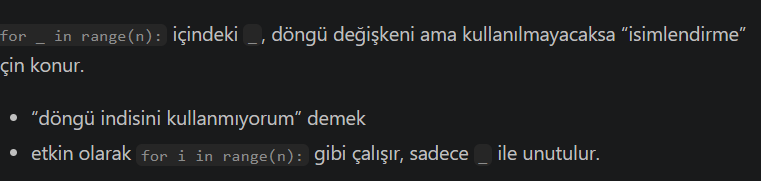
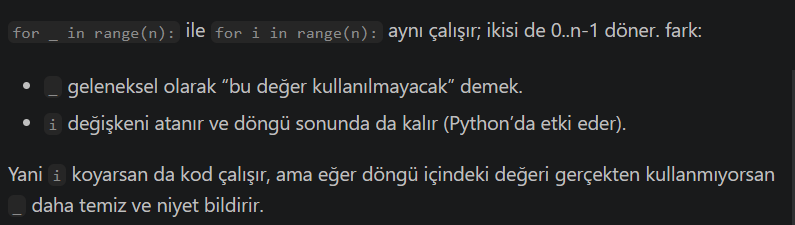

In [ ]:
def predict_next_word(seed_text, next_words):
    """ Bu fonksiyon, verilen başlangıç metninin sonuna modelin tahmin ettiği yeni kelimeleri ekler."""
    for _ in range(next_words):
        # Metni tokenizer yardımıyla sayısal bir diziye dönüştürüyoruz.
        token_list = tokenizer.texts_to_sequences([seed_text])[0]

        # Dizi uzunluğunu modele uygun hale getirmek için padding uyguluyoruz.
        token_list = pad_sequences([token_list], maxlen=max_sequence_len - 1, padding='pre')

        # Model, bir sonraki kelimeye ait olasılık değerlerini üretiyor.
        predicted_probs = model.predict(token_list, verbose=0)

        # En yüksek olasılığa sahip kelimenin indeksini seçiyoruz.
        predicted_word_index = np.argmax(predicted_probs, axis=-1)[0]

        # Seçilen indeksi tekrar kelimeye çeviriyoruz.
        predicted_word = tokenizer.index_word.get(predicted_word_index, "")

        # Tahmin edilen kelimeyi mevcut metnin sonuna ekliyoruz.
        seed_text += " " + predicted_word

    # Belirtilen sayıda kelime eklendikten sonra oluşan yeni metni döndürüyoruz.
    return seed_text


In [34]:
predict_next_word("Bugün hava", 2)

'Bugün hava çok güzel'